# Predicción de Riesgo de Incumplimiento de Pago (Home Credit Default Risk)
Dataset: `application_train.csv` (307.511 registros, 122 columnas originales)

## Índice

1. [Comprensión del problema](#1)
2. [Análisis exploratorio de datos (EDA)](#2)
3. [Preparación de los datos](#3)
4. [Reducción de dimensionalidad](#4)
5. [Construcción del modelo](#5)
6. [Evaluación del modelo](#6)
7. [Interpretación del modelo y conclusiones](#7)
8. [Exportación del modelo](#8)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    precision_recall_curve, classification_report
)
import joblib

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

def formato_miles(x, pos):
    """Formatea un eje numérico grande como 1.2M / 350K, para legibilidad en los gráficos."""
    if abs(x) >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif abs(x) >= 1_000:
        return f'{x/1_000:.0f}K'
    return f'{x:.0f}'


In [2]:
DATA_PATH = "../data/input/application_train.csv"  # AJUSTAR segun necesidad

df_raw = pd.read_csv(DATA_PATH)
print(f"Dimensiones originales: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
df_raw.head()


Dimensiones originales: 307,511 filas x 122 columnas


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

**1. Comprensión del Problema**

Problema de negocio: las instituciones financieras pierden dinero cuando otorgan créditos a clientes que no pagan, pero también pierden ingresos si rechazan solicitudes de clientes que sí habrían pagado. Objetivo: predecir la probabilidad de que un solicitante incurra en dificultades de pago (default), usando la información disponible al momento de la solicitud.

Variable objetivo: `TARGET` (renombrada `incumplimiento`, binaria: 1 = dificultades de pago, 0 = pago normal).
Tipo de problema: Clasificación binaria.
Beneficio esperado: reducir la morosidad de la cartera y aprobar más clientes de bajo riesgo hoy rechazados por criterios manuales conservadores.

**Diccionario de columnas y filtrado inicial**

Filtrado por criterio de facilitación de aprendizaje (no por resultados del EDA, que viene después), descartando bloques de bajo valor analítico: flags administrativos de documentos, flags de contacto, bloque de características del edificio (alto % de nulos), y ventanas redundantes de consultas al buró. Se renombra a español para legibilidad. 

In [3]:
column_mapping = {
    "SK_ID_CURR": "id_cliente",
    "TARGET": "incumplimiento",
    "NAME_CONTRACT_TYPE": "tipo_contrato",
    "AMT_INCOME_TOTAL": "ingreso_total_anual",
    "AMT_CREDIT": "monto_credito",
    "AMT_ANNUITY": "cuota_anual",
    "AMT_GOODS_PRICE": "precio_bien_financiado",
    "CODE_GENDER": "genero",
    "FLAG_OWN_CAR": "tiene_auto",
    "FLAG_OWN_REALTY": "tiene_propiedad",
    "CNT_CHILDREN": "cantidad_hijos",
    "CNT_FAM_MEMBERS": "cantidad_miembros_familia",
    "NAME_FAMILY_STATUS": "estado_civil",
    "NAME_EDUCATION_TYPE": "nivel_educacional",
    "NAME_HOUSING_TYPE": "tipo_vivienda",
    "NAME_TYPE_SUITE": "acompanante_solicitud",
    "NAME_INCOME_TYPE": "tipo_ingreso",
    "OCCUPATION_TYPE": "ocupacion",
    "ORGANIZATION_TYPE": "rubro_empleador",
    "DAYS_BIRTH": "dias_nacimiento",
    "DAYS_EMPLOYED": "dias_empleo",
    "OWN_CAR_AGE": "antiguedad_auto",
    "REGION_POPULATION_RELATIVE": "densidad_poblacional_region",
    "REGION_RATING_CLIENT": "calificacion_region_cliente",
    "EXT_SOURCE_1": "score_externo_1",
    "EXT_SOURCE_2": "score_externo_2",
    "EXT_SOURCE_3": "score_externo_3",
    "OBS_30_CNT_SOCIAL_CIRCLE": "observaciones_circulo_social_30d",
    "DEF_30_CNT_SOCIAL_CIRCLE": "incumplimientos_circulo_social_30d",
    "OBS_60_CNT_SOCIAL_CIRCLE": "observaciones_circulo_social_60d",
    "DEF_60_CNT_SOCIAL_CIRCLE": "incumplimientos_circulo_social_60d",
    "AMT_REQ_CREDIT_BUREAU_YEAR": "consultas_buro_credito_anual",
    "WEEKDAY_APPR_PROCESS_START": "dia_semana_solicitud",
    "HOUR_APPR_PROCESS_START": "hora_solicitud",
    "REG_REGION_NOT_LIVE_REGION": "discrepancia_region_registro_residencia",
    "REG_CITY_NOT_WORK_CITY": "discrepancia_ciudad_registro_trabajo",
}

cols_presentes = [c for c in column_mapping if c in df_raw.columns]
df = df_raw[cols_presentes].rename(columns=column_mapping)

print(f"Dimensiones tras filtrado inicial: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"(Se descartaron {df_raw.shape[1] - df.shape[1]} de las {df_raw.shape[1]} columnas originales)")
df.head()


Dimensiones tras filtrado inicial: 307,511 filas x 36 columnas
(Se descartaron 86 de las 122 columnas originales)


,id_cliente,incumplimiento,tipo_contrato,ingreso_total_anual,monto_credito,cuota_anual,precio_bien_financiado,genero,tiene_auto,tiene_propiedad,cantidad_hijos,cantidad_miembros_familia,estado_civil,nivel_educacional,tipo_vivienda,acompanante_solicitud,tipo_ingreso,ocupacion,rubro_empleador,dias_nacimiento,dias_empleo,antiguedad_auto,densidad_poblacional_region,calificacion_region_cliente,score_externo_1,score_externo_2,score_externo_3,observaciones_circulo_social_30d,incumplimientos_circulo_social_30d,observaciones_circulo_social_60d,incumplimientos_circulo_social_60d,consultas_buro_credito_anual,dia_semana_solicitud,hora_solicitud,discrepancia_region_registro_residencia,discrepancia_ciudad_registro_trabajo
0,100002,1,Cash loans,202500.0,406597.5,24700.5,351000.0,M,N,Y,0,1.0,Single / not married,Secondary / secondary special,House / apartment,Unaccompanied,Working,Laborers,Business Entity Type 3,-9461,-637,NaN,0.018801,2,0.083037,0.262949,0.139376,2.0,2.0,2.0,2.0,1.0,WEDNESDAY,10,0,0
1,100003,0,Cash loans,270000.0,1293502.5,35698.5,1129500.0,F,N,N,0,2.0,Married,Higher education,House / apartment,Family,State servant,Core staff,School,-16765,-1188,NaN,0.003541,1,0.311267,0.622246,NaN,1.0,0.0,1.0,0.0,0.0,MONDAY,11,0,0
2,100004,0,Revolving loans,67500.0,135000.0,6750.0,135000.0,M,Y,Y,0,1.0,Single / not married,Secondary / secondary special,House / apartment,Unaccompanied,Working,Laborers,Government,-19046,-225,26.0,0.010032,2,NaN,0.555912,0.729567,0.0,0.0,0.0,0.0,0.0,MONDAY,9,0,0
3,100006,0,Cash loans,135000.0,312682.5,29686.5,297000.0,F,N,Y,0,2.0,Civil marriage,Secondary / secondary special,House / apartment,Unaccompanied,Working,Laborers,Business Entity Type 3,-19005,-3039,NaN,0.008019,2,NaN,0.650442,NaN,2.0,0.0,2.0,0.0,NaN,WEDNESDAY,17,0,0
4,100007,0,Cash loans,121500.0,513000.0,21865.5,513000.0,M,N,Y,0,1.0,Single / not married,Secondary / secondary special,House / apartment,Unaccompanied,Working,Core staff,Religion,-19932,-3038,NaN,0.028663,2,NaN,0.322738,NaN,0.0,0.0,0.0,0.0,0.0,THURSDAY,11,0,1


In [4]:
# dias_nacimiento / dias_empleo vienen en días negativos -> se transforman a años.
# DAYS_EMPLOYED trae un valor centinela (365243 ~ 1000 años) para clientes sin empleo activo.
df["dias_empleo"] = df["dias_empleo"].replace(365243, np.nan)

df["edad_anios"] = (-df["dias_nacimiento"] / 365.25).round(1)
df["antiguedad_laboral_anios"] = (-df["dias_empleo"] / 365.25).round(1)

df = df.drop(columns=["dias_nacimiento", "dias_empleo"])

print(f"Dimensiones finales tras derivar variables de edad/antigüedad: {df.shape}")
df[["edad_anios", "antiguedad_laboral_anios"]].describe()


Dimensiones finales tras derivar variables de edad/antigüedad: (307511, 36)


,edad_anios,antiguedad_laboral_anios
count,307511.000000,252137.000000
mean,43.906968,6.527443
std,11.947987,6.402172
min,20.500000,0.000000
25%,34.000000,2.100000
50%,43.100000,4.500000
75%,53.900000,8.700000
max,69.100000,49.000000


**2. Análisis Exploratorio de Datos (EDA)** — sobre `df` ya curado

In [5]:
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(df.dtypes.value_counts())


Filas: 307,511 | Columnas: 36
float64    17
str        12
int64       7
Name: count, dtype: int64


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 36 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   id_cliente                               307511 non-null  int64  
 1   incumplimiento                           307511 non-null  int64  
 2   tipo_contrato                            307511 non-null  str    
 3   ingreso_total_anual                      307511 non-null  float64
 4   monto_credito                            307511 non-null  float64
 5   cuota_anual                              307499 non-null  float64
 6   precio_bien_financiado                   307233 non-null  float64
 7   genero                                   307511 non-null  str    
 8   tiene_auto                               307511 non-null  str    
 9   tiene_propiedad                          307511 non-null  str    
 10  cantidad_hijos                           30

In [7]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100
tabla_nulos = pd.DataFrame({"n_nulos": nulos, "pct_nulos": pct_nulos})
tabla_nulos = tabla_nulos[tabla_nulos["n_nulos"] > 0].sort_values("pct_nulos", ascending=False)
print(f"Columnas con al menos un nulo: {len(tabla_nulos)} de {df.shape[1]}")
tabla_nulos


Columnas con al menos un nulo: 15 de 36


,n_nulos,pct_nulos
antiguedad_auto,202929,65.990810
score_externo_1,173378,56.381073
ocupacion,96391,31.345545
score_externo_3,60965,19.825307
antiguedad_laboral_anios,55374,18.007161
consultas_buro_credito_anual,41519,13.501631
acompanante_solicitud,1292,0.420148
incumplimientos_circulo_social_60d,1021,0.332021
incumplimientos_circulo_social_30d,1021,0.332021
observaciones_circulo_social_60d,1021,0.332021


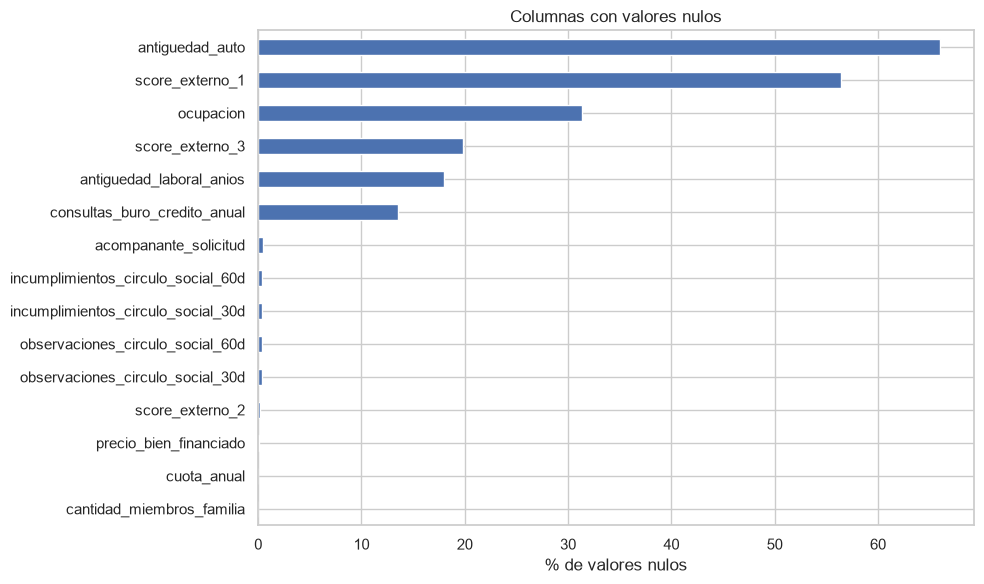

In [8]:
plt.figure(figsize=(10, 6))
tabla_nulos["pct_nulos"].plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("% de valores nulos")
plt.title("Columnas con valores nulos")
plt.tight_layout()
plt.show()


Encontramos una cantidad relevante de nulos en algunas variables, por lo que se tendrá que investigar más a fondo y tomar decisiones para cada una.

In [9]:
n_duplicados = df.duplicated().sum()
n_duplicados_id = df["id_cliente"].duplicated().sum()
print(f"Filas completamente duplicadas: {n_duplicados}")
print(f"IDs de cliente duplicados: {n_duplicados_id}")


Filas completamente duplicadas: 0
IDs de cliente duplicados: 0


In [10]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id_cliente,307511.0,278180.518577,102790.175348,1.000020e+05,189145.500000,278202.000000,367142.500000,4.562550e+05
incumplimiento,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
ingreso_total_anual,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
monto_credito,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
cuota_anual,307499.0,27108.573909,14493.737315,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
precio_bien_financiado,307233.0,538396.207429,369446.460540,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
cantidad_hijos,307511.0,0.417052,0.722121,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
cantidad_miembros_familia,307509.0,2.152665,0.910682,1.000000e+00,2.000000,2.000000,3.000000,2.000000e+01
antiguedad_auto,104582.0,12.061091,11.944812,0.000000e+00,5.000000,9.000000,15.000000,9.100000e+01
densidad_poblacional_region,307511.0,0.020868,0.013831,2.900000e-04,0.010006,0.018850,0.028663,7.250800e-02


In [11]:
df.describe(include="object").T

,count,unique,top,freq
tipo_contrato,307511,2,Cash loans,278232
genero,307511,3,F,202448
tiene_auto,307511,2,N,202924
tiene_propiedad,307511,2,Y,213312
estado_civil,307511,6,Married,196432
nivel_educacional,307511,5,Secondary / secondary special,218391
tipo_vivienda,307511,6,House / apartment,272868
acompanante_solicitud,306219,7,Unaccompanied,248526
tipo_ingreso,307511,8,Working,158774
ocupacion,211120,18,Laborers,55186


Las variables `rubro_empleador` y `ocupacion` aumentarían bastante la dimensión al aplicar One Hot Encoding.

incumplimiento
0    282686
1     24825
Name: count, dtype: int64
incumplimiento
0    91.93
1     8.07
Name: proportion, dtype: float64


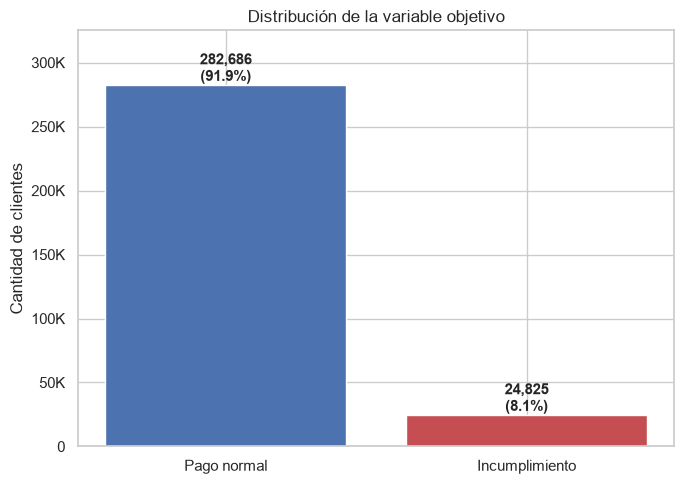

In [12]:
target_counts = df["incumplimiento"].value_counts().sort_index()
target_pct = (df["incumplimiento"].value_counts(normalize=True) * 100).sort_index()
print(target_counts)
print(target_pct.round(2))

fig, ax = plt.subplots(figsize=(7, 5))
colores = ["#4C72B0", "#C44E52"]
etiquetas = ["Pago normal", "Incumplimiento"]
barras = ax.bar(etiquetas, target_counts, color=colores)
for barra, count, pct in zip(barras, target_counts, target_pct):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 3000,
            f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title("Distribución de la variable objetivo")
ax.set_ylabel("Cantidad de clientes")
ax.set_ylim(0, target_counts.max() * 1.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formato_miles))
plt.tight_layout()
plt.show()


Se ve que nuestra variable objetivo está claramente desbalanceada, por lo que habrá que tomar decisiones respecto a esto (ej. `class_weight='balanced'` en los modelos).

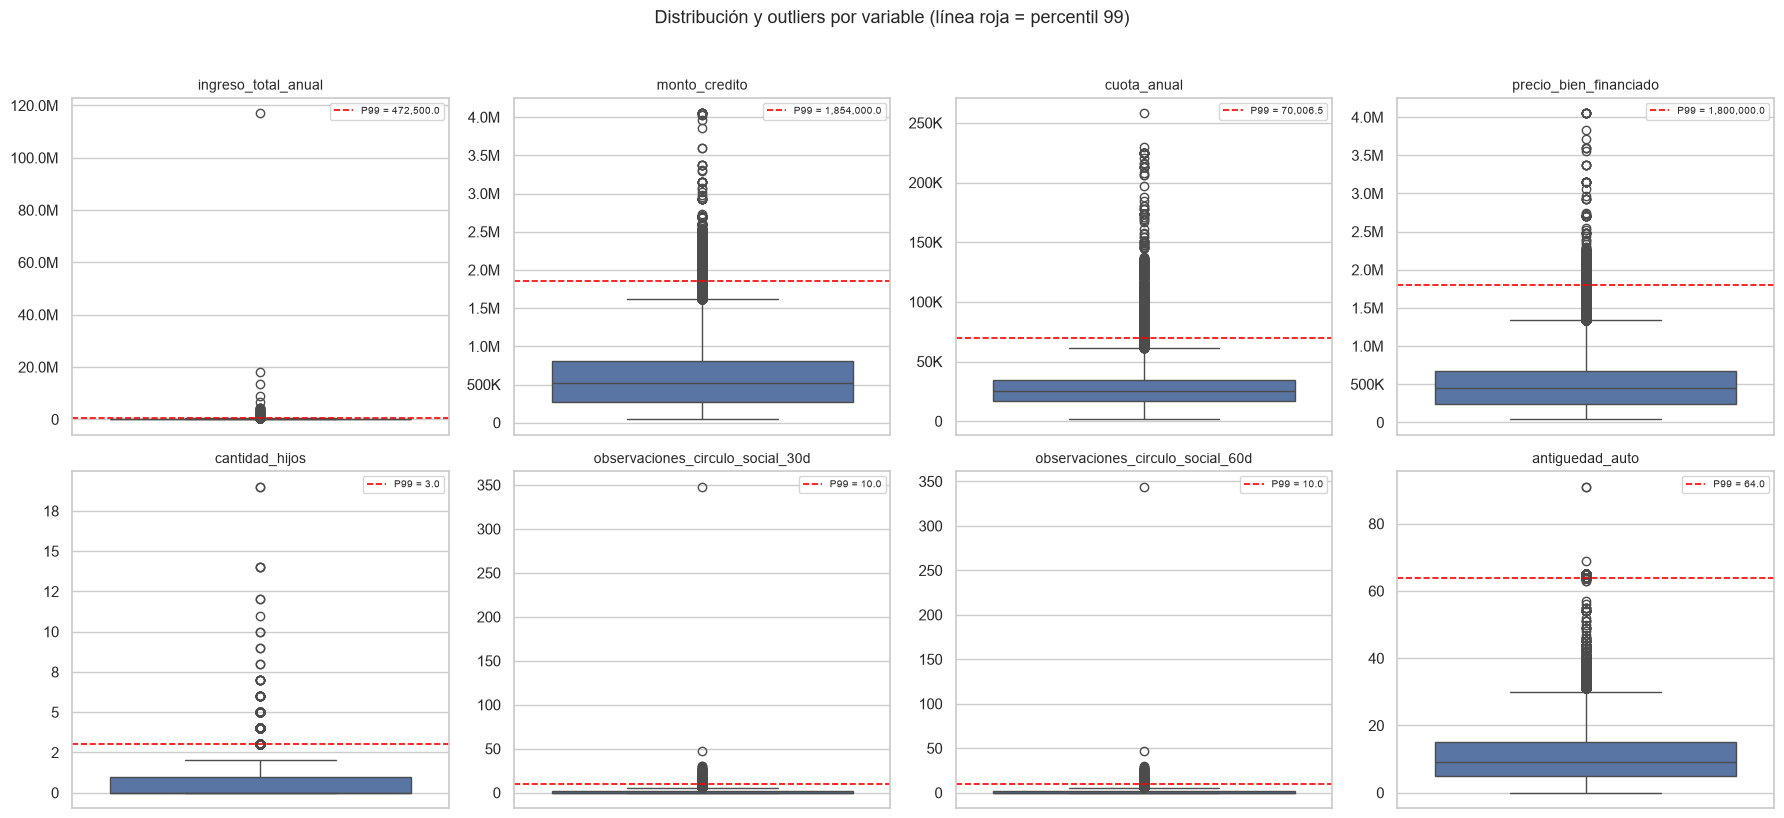

In [13]:
# Detección explícita de outliers (monetarias + conteos + antigüedad_auto)
cols_revisar = ["ingreso_total_anual", "monto_credito", "cuota_anual", "precio_bien_financiado",
                 "cantidad_hijos", "observaciones_circulo_social_30d", "observaciones_circulo_social_60d",
                 "antiguedad_auto"]

# --- Boxplots para visualizar los outliers de las 8 variables ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, col in zip(axes.flatten(), cols_revisar):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    p99 = df[col].quantile(0.99)
    ax.axhline(p99, color="red", linestyle="--", linewidth=1.2, label=f"P99 = {p99:,.1f}")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")
    ax.legend(fontsize=7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(formato_miles))

plt.suptitle("Distribución y outliers por variable (línea roja = percentil 99)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Se ven dos tipos distintos de valores extremos: asimetría de negocio legítima en las variables monetarias (monto_credito, cuota_anual, precio_bien_financiado), y outliers aislados que sugieren errores de captura en ingreso_total_anual, cantidad_hijos y los conteos de círculo social, donde un único registro se aleja del resto de la distribución.

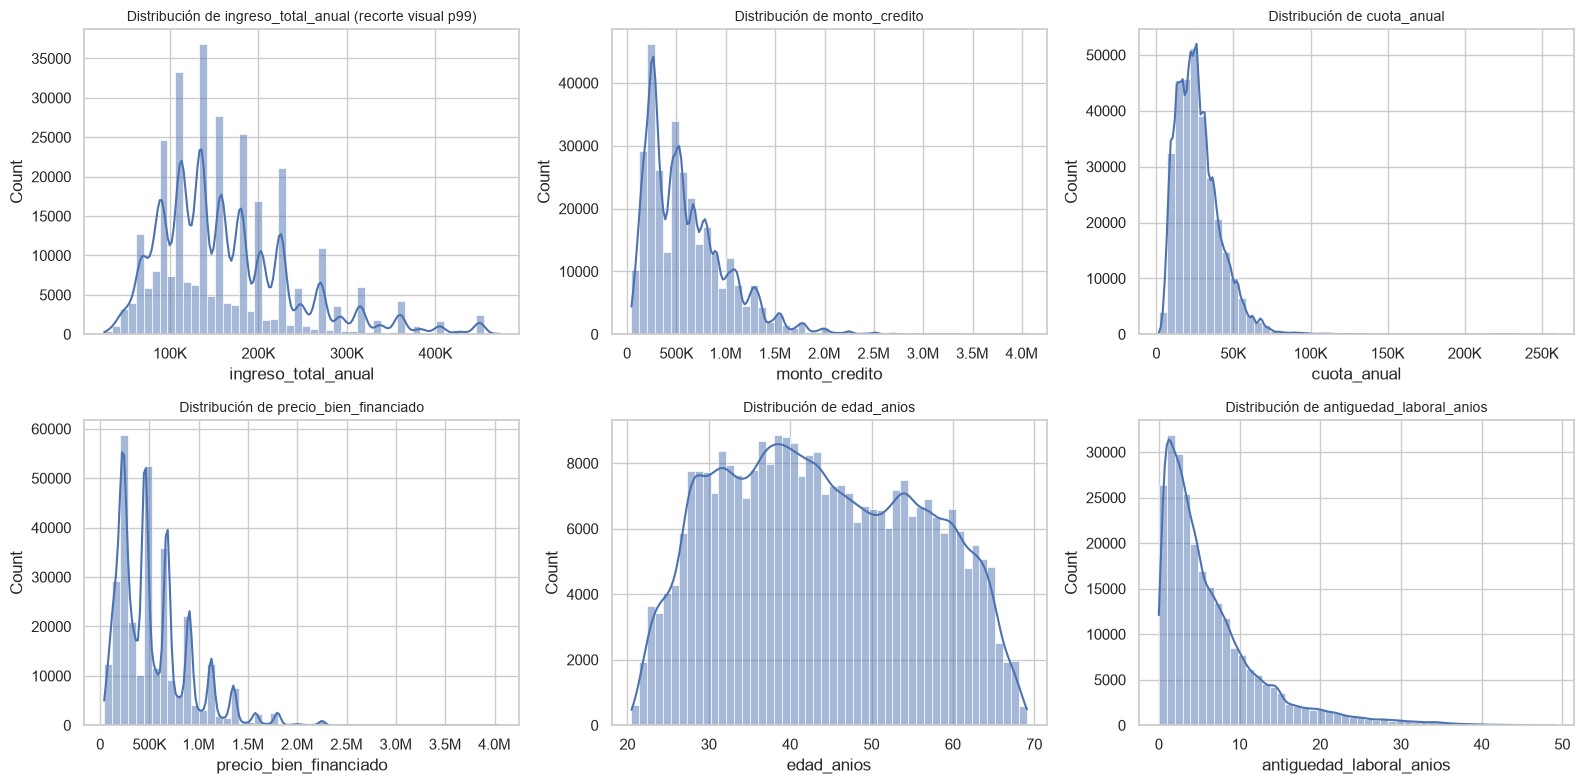

In [14]:
num_cols_interes = ["ingreso_total_anual", "monto_credito", "cuota_anual",
                    "precio_bien_financiado", "edad_anios", "antiguedad_laboral_anios"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols_interes):
    if col == "ingreso_total_anual":
        limite = df[col].quantile(0.99)
        data_plot = df[df[col] <= limite][col]
        extra = " (recorte visual p99)"
    else:
        data_plot = df[col]
        extra = ""
    sns.histplot(data_plot, kde=True, ax=ax, bins=50)
    ax.set_title(f"Distribución de {col}{extra}", fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(formato_miles))
plt.tight_layout()
plt.show()


Se observa que `edad_anios` distribuye similar a una normal, mientras que todas las demás variables graficadas tienen una asimetría positiva.

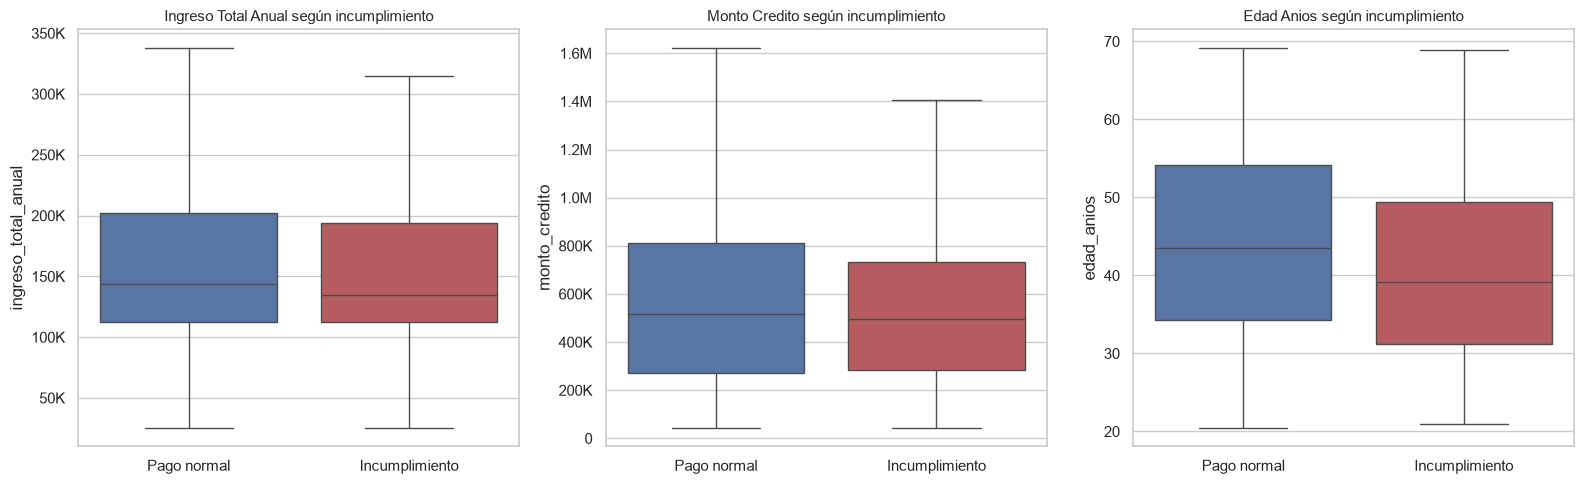

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
etiquetas_target = {0: "Pago normal", 1: "Incumplimiento"}
palette_dict = {"Pago normal": "#4C72B0", "Incumplimiento": "#C44E52"}

for ax, col in zip(axes, ["ingreso_total_anual", "monto_credito", "edad_anios"]):
    if col == "ingreso_total_anual":
        limite = df[col].quantile(0.99)
        data_plot = df[df[col] <= limite].copy()
    else:
        data_plot = df.copy()
    data_plot["incumplimiento_label"] = data_plot["incumplimiento"].map(etiquetas_target)
    sns.boxplot(x="incumplimiento_label", y=col, data=data_plot, ax=ax,
                order=["Pago normal", "Incumplimiento"], palette=palette_dict, showfliers=False)
    ax.set_title(f"{col.replace('_', ' ').title()} según incumplimiento", fontsize=11)
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(formato_miles))
plt.tight_layout()
plt.show()


A primera vista se ve que no existe mucha diferencia por las variables graficadas segun el incumplimiento, la diferencia mas notable es que los incumplidores tienen un promedio de edad mas bajo.

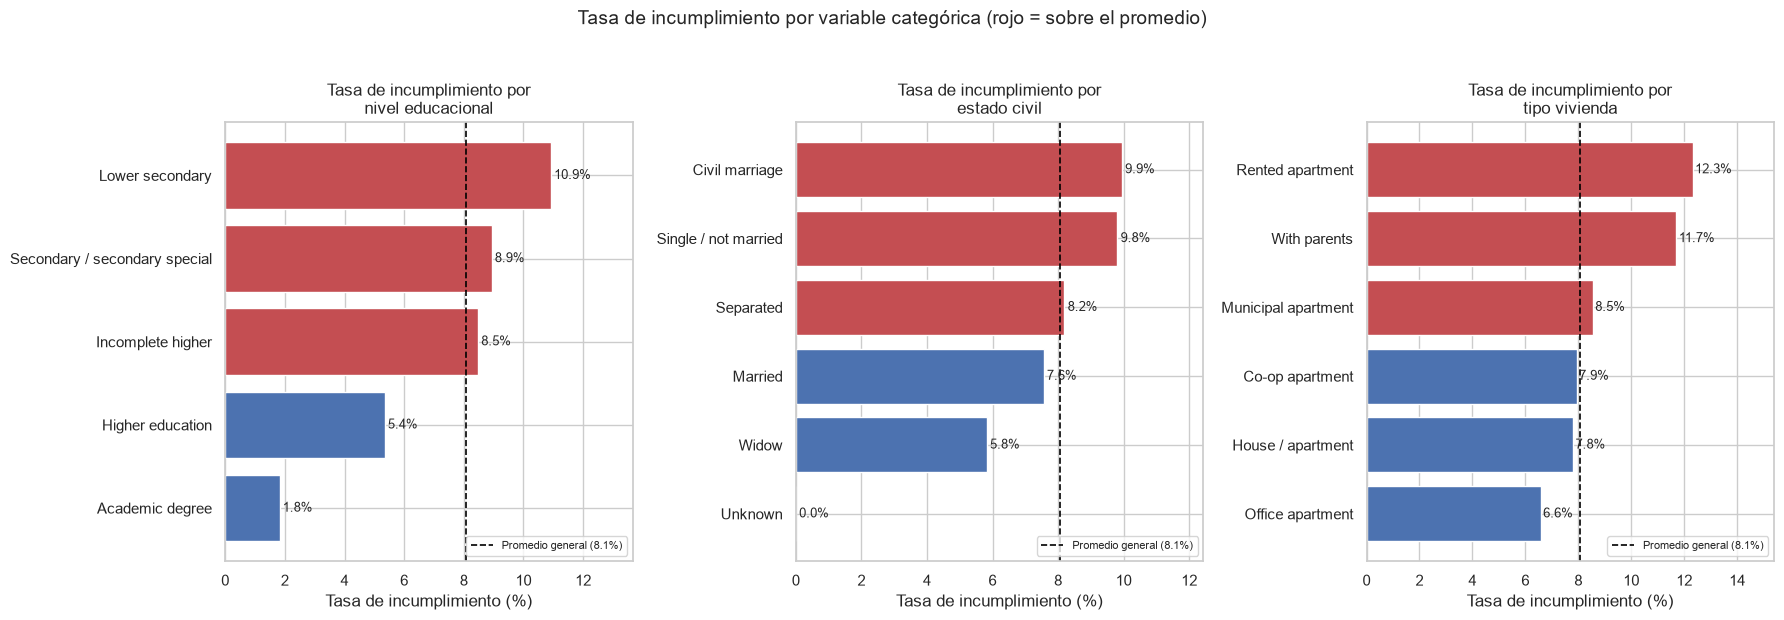


--- Tasa de incumplimiento por nivel_educacional ---
nivel_educacional
Lower secondary                  0.109
Secondary / secondary special    0.089
Incomplete higher                0.085
Higher education                 0.054
Academic degree                  0.018
Name: incumplimiento, dtype: float64

--- Tasa de incumplimiento por estado_civil ---
estado_civil
Civil marriage          0.099
Single / not married    0.098
Separated               0.082
Married                 0.076
Widow                   0.058
Unknown                 0.000
Name: incumplimiento, dtype: float64

--- Tasa de incumplimiento por tipo_vivienda ---
tipo_vivienda
Rented apartment       0.123
With parents           0.117
Municipal apartment    0.085
Co-op apartment        0.079
House / apartment      0.078
Office apartment       0.066
Name: incumplimiento, dtype: float64


In [16]:
cols_categoricas = ["nivel_educacional", "estado_civil", "tipo_vivienda"]
tasa_promedio_global = df["incumplimiento"].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col in zip(axes, cols_categoricas):
    tasas = df.groupby(col)["incumplimiento"].mean().sort_values(ascending=True) * 100
    colores_barras = ["#C44E52" if v/100 > tasa_promedio_global else "#4C72B0" for v in tasas]
    barras = ax.barh(tasas.index, tasas.values, color=colores_barras)
    ax.axvline(tasa_promedio_global * 100, color="black", linestyle="--", linewidth=1.2,
               label=f"Promedio general ({tasa_promedio_global*100:.1f}%)")
    for barra, valor in zip(barras, tasas.values):
        ax.text(barra.get_width() + 0.1, barra.get_y() + barra.get_height()/2,
                f'{valor:.1f}%', va='center', fontsize=9)
    ax.set_title(f"Tasa de incumplimiento por\n{col.replace('_', ' ')}", fontsize=12)
    ax.set_xlabel("Tasa de incumplimiento (%)")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_xlim(0, tasas.max() * 1.25)
plt.suptitle("Tasa de incumplimiento por variable categórica (rojo = sobre el promedio)", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

for col in cols_categoricas:
    print(f"\n--- Tasa de incumplimiento por {col} ---")
    print(df.groupby(col)["incumplimiento"].mean().sort_values(ascending=False).round(3))


Las variables “nivel_educacional”, “tipo_vivienda” y “estado_civil” muestran una relación clara con el riesgo de incumplimiento. En los tres casos se observa una mayor proporción de clientes morosos entre quienes tienen un menor nivel educacional, no poseen vivienda propia o son solteros o viven en unión civil.

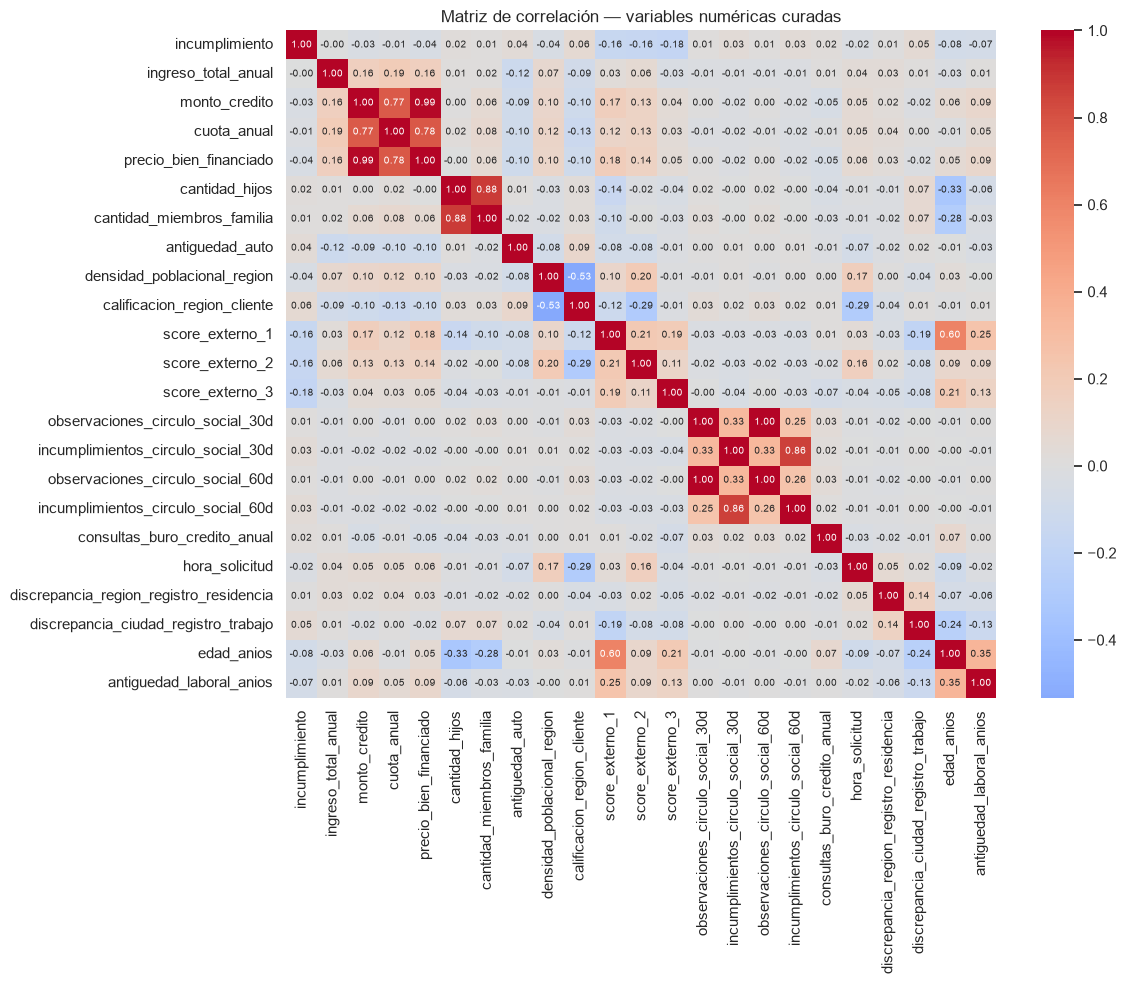

incumplimiento                             1.000000
score_externo_3                            0.178919
score_externo_2                            0.160472
score_externo_1                            0.155317
edad_anios                                 0.078234
antiguedad_laboral_anios                   0.074971
calificacion_region_cliente                0.058899
discrepancia_ciudad_registro_trabajo       0.050994
precio_bien_financiado                     0.039645
antiguedad_auto                            0.037612
densidad_poblacional_region                0.037227
incumplimientos_circulo_social_30d         0.032248
incumplimientos_circulo_social_60d         0.031276
monto_credito                              0.030369
hora_solicitud                             0.024166
consultas_buro_credito_anual               0.019930
cantidad_hijos                             0.019187
cuota_anual                                0.012817
cantidad_miembros_familia                  0.009308
observacione

In [17]:
num_cols = df.select_dtypes(include=[np.number]).columns
cols_corr = [c for c in num_cols if c != "id_cliente"]

plt.figure(figsize=(12, 10))
sns.heatmap(df[cols_corr].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Matriz de correlación — variables numéricas curadas")
plt.tight_layout()
plt.show()

df[cols_corr].corr()["incumplimiento"].abs().sort_values(ascending=False)


Las variables “score_externo_1”, “score_externo_2” y “score_externo_3” presentan la mayor correlación con la variable objetivo, lo que es esperable, ya que fueron diseñadas para medir el riesgo crediticio de los clientes. Además, se observa una fuerte correlación entre “edad_anios” y “score_externo_1”.

**3. Preparación de los Datos**

Orden: eliminar duplicados -> split train/test -> tratamiento de nulos -> tratamiento de outliers -> encoding

In [18]:
df = df.drop_duplicates(subset="id_cliente")
print(f"Dimensiones tras eliminar duplicados: {df.shape}")


Dimensiones tras eliminar duplicados: (307511, 36)


En este caso no existen duplicados, pero se realiza la verificación como buena práctica.

In [19]:
X = df.drop(columns=["incumplimiento", "id_cliente"])
y = df["incumplimiento"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Tasa de incumplimiento en train: {y_train.mean():.3f} | en test: {y_test.mean():.3f}")


Train: (246008, 34) | Test: (61503, 34)
Tasa de incumplimiento en train: 0.081 | en test: 0.081


Tratamiento de nulos. Se distinguen dos casos: nulos "informativos" (el nulo tiene un significado de negocio, no es un dato faltante al azar) y nulos genéricos (se imputan con mediana/moda vía pipeline en 3.5-3.6).

`antiguedad_auto`: nula principalmente porque el cliente no tiene auto (`tiene_auto == "N"`), no porque falte el dato -> se imputa 0 en ese caso, mediana solo para los pocos casos con auto y dato faltante.
`ocupacion`: 31% de nulos; imputar con la moda distorsionaría el peso real de esa categoría -> se crea la categoría explícita "Sin_informacion".

In [20]:
# antiguedad_auto: nulo == sin auto -> se imputa 0
for df_split in (X_train, X_test):
    mask_sin_auto = df_split["tiene_auto"] == "N"
    df_split.loc[mask_sin_auto & df_split["antiguedad_auto"].isna(), "antiguedad_auto"] = 0

# antiguedad_auto: nulo con auto == dato faltante real -> se imputa con la mediana (calculada solo en train)
mediana_auto_con_auto = X_train.loc[X_train["tiene_auto"] == "Y", "antiguedad_auto"].median()
for df_split in (X_train, X_test):
    mask_con_auto = df_split["tiene_auto"] == "Y"
    df_split.loc[mask_con_auto & df_split["antiguedad_auto"].isna(), "antiguedad_auto"] = mediana_auto_con_auto

# ocupacion: se deja como categoría explícita en vez de imputar con la moda
for df_split in (X_train, X_test):
    df_split["ocupacion"] = df_split["ocupacion"].fillna("Sin_informacion")

print("Nulos remanentes en antiguedad_auto (train):", X_train["antiguedad_auto"].isna().sum())
print("Nulos remanentes en ocupacion (train):", X_train["ocupacion"].isna().sum())


Nulos remanentes en antiguedad_auto (train): 0
Nulos remanentes en ocupacion (train): 0


Tratamiento de valores extremos (capping al percentil 1-99), calculado solo con train y aplicado a ambos conjuntos.

In [21]:
# lista fija: todas las variables numéricas relevantes, no solo las 8 revisadas visualmente antes
cols_para_capping = ["ingreso_total_anual", "monto_credito", "cuota_anual", "precio_bien_financiado",
                      "cantidad_hijos", "observaciones_circulo_social_30d", "observaciones_circulo_social_60d",
                      "antiguedad_auto", "score_externo_1", "score_externo_2", "score_externo_3",
                      "densidad_poblacional_region", "calificacion_region_cliente",
                      "incumplimientos_circulo_social_30d", "incumplimientos_circulo_social_60d",
                      "consultas_buro_credito_anual", "cantidad_miembros_familia",
                      "edad_anios", "antiguedad_laboral_anios"]

# límites calculados solo con train, aplicados a train y test por igual
limites_cap = {}
for col in cols_para_capping:
    p1 = X_train[col].quantile(0.01)
    p99 = X_train[col].quantile(0.99)
    limites_cap[col] = (p1, p99)
    X_train[col] = X_train[col].clip(lower=p1, upper=p99)
    X_test[col] = X_test[col].clip(lower=p1, upper=p99)

print("Límites de capping aplicados (calculados sobre train):")
for col, (p1, p99) in limites_cap.items():
    print(f"  {col}: [{p1:,.1f}, {p99:,.1f}]")


Límites de capping aplicados (calculados sobre train):
  ingreso_total_anual: [45,000.0, 472,500.0]
  monto_credito: [76,410.0, 1,862,802.0]
  cuota_anual: [6,187.5, 70,033.5]
  precio_bien_financiado: [67,500.0, 1,800,000.0]
  cantidad_hijos: [0.0, 3.0]
  observaciones_circulo_social_30d: [0.0, 10.0]
  observaciones_circulo_social_60d: [0.0, 10.0]
  antiguedad_auto: [0.0, 64.0]
  score_externo_1: [0.1, 0.9]
  score_externo_2: [0.0, 0.8]
  score_externo_3: [0.1, 0.8]
  densidad_poblacional_region: [0.0, 0.1]
  calificacion_region_cliente: [1.0, 3.0]
  incumplimientos_circulo_social_30d: [0.0, 2.0]
  incumplimientos_circulo_social_60d: [0.0, 2.0]
  consultas_buro_credito_anual: [0.0, 8.0]
  cantidad_miembros_familia: [1.0, 5.0]
  edad_anios: [22.6, 66.8]
  antiguedad_laboral_anios: [0.3, 31.0]


Codificación de categóricas (One-Hot, sin orden natural entre categorías) y escalamiento de numéricas (`StandardScaler`), vía pipeline ajustado solo con train.

In [22]:
# aquí se recalculan num_features/cat_features sobre TODAS las columnas de X_train (no solo las de capping)
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object"]).columns.tolist()
print(f"Numéricas: {len(num_features)} | Categóricas: {len(cat_features)}")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

feature_names = (num_features +
                  list(preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(cat_features)))

print(f"Dimensiones tras preprocesamiento: {X_train_prep.shape}")


Numéricas: 22 | Categóricas: 12
Dimensiones tras preprocesamiento: (246008, 147)


**4. Reducción de Dimensionalidad**

Criterio estadístico, distinto y posterior al filtrado de negocio de 1.5, aplicado sobre el conjunto ya preprocesado.

In [23]:
# 4.1 Cálculo de scores ANOVA para todas las variables, SIN aplicar corte todavía
f_scores, p_values = f_classif(X_train_prep, y_train)
scores_df = pd.DataFrame({"feature": feature_names, "score": f_scores, "p_value": p_values})
scores_df_sorted = scores_df.sort_values("score", ascending=False).reset_index(drop=True)

print(f"Total de variables evaluadas: {len(scores_df_sorted)}")
scores_df_sorted.head(15)


Total de variables evaluadas: 147


,feature,score,p_value
0,score_externo_2,6388.170916,0.000000e+00
1,score_externo_3,6121.600576,0.000000e+00
2,score_externo_1,2412.095807,0.000000e+00
3,edad_anios,1562.538687,0.000000e+00
4,antiguedad_laboral_anios,1011.722487,1.437620e-221
5,calificacion_region_cliente,857.771827,3.138312e-188
6,nivel_educacional_Higher education,766.140474,2.254894e-168
7,tipo_ingreso_Working,762.738730,1.231623e-167
8,genero_M,735.073386,1.223701e-161
9,genero_F,734.927765,1.315966e-161


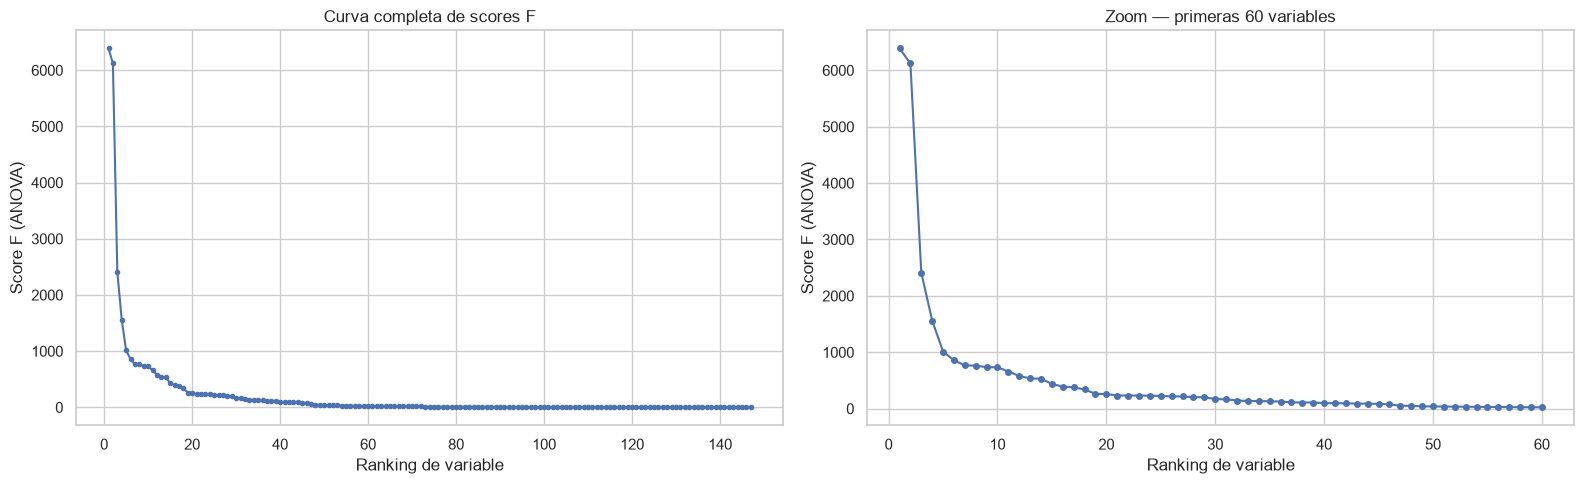

In [24]:
# 4.2 Determinación de k -- scree plot SIN marcar k (evita razonamiento circular)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(range(1, len(scores_df_sorted) + 1), scores_df_sorted["score"], marker="o", markersize=3)
axes[0].set_xlabel("Ranking de variable")
axes[0].set_ylabel("Score F (ANOVA)")
axes[0].set_title("Curva completa de scores F")

top_n = 60
axes[1].plot(range(1, top_n + 1), scores_df_sorted["score"].head(top_n), marker="o", markersize=4)
axes[1].set_xlabel("Ranking de variable")
axes[1].set_ylabel("Score F (ANOVA)")
axes[1].set_title(f"Zoom — primeras {top_n} variables")
plt.tight_layout()
plt.show()


La fuerte caída inicial y el posterior aplanamiento indican que, después de las primeras variables, el aporte de información disminuye considerablemente.  

     k  roc_auc_promedio
0   10          0.733900
1   20          0.734923
2   30          0.737230
3   40          0.737517
4   50          0.736917
5   70          0.735922
6  100          0.734117
7  144          0.732455


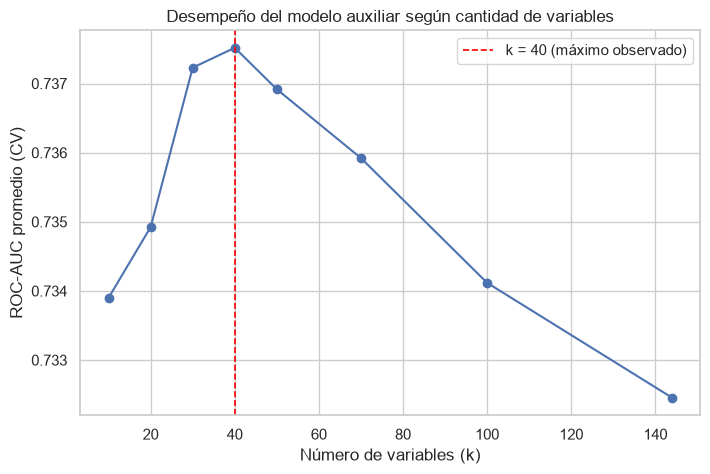

In [25]:
# Confirmación cuantitativa: ROC-AUC vs k, con un modelo auxiliar (no es el modelo final)
valores_k = [10, 20, 30, 40, 50, 70, 100, 144]
resultados_k = []
for k in valores_k:
    selector_temp = SelectKBest(score_func=f_classif, k=k)
    X_sel_temp = selector_temp.fit_transform(X_train_prep, y_train)
    modelo_auxiliar = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight="balanced",
                                              random_state=RANDOM_STATE, n_jobs=-1)
    scores_cv = cross_val_score(modelo_auxiliar, X_sel_temp, y_train, cv=3, scoring="roc_auc", n_jobs=-1)
    resultados_k.append({"k": k, "roc_auc_promedio": scores_cv.mean()})

resultados_k_df = pd.DataFrame(resultados_k)
print(resultados_k_df)

k_optimo = int(resultados_k_df.loc[resultados_k_df["roc_auc_promedio"].idxmax(), "k"])

plt.figure(figsize=(8, 5))
plt.plot(resultados_k_df["k"], resultados_k_df["roc_auc_promedio"], marker="o")
plt.axvline(k_optimo, color="red", linestyle="--", linewidth=1.2, label=f"k = {k_optimo} (máximo observado)")
plt.xlabel("Número de variables (k)")
plt.ylabel("ROC-AUC promedio (CV)")
plt.title("Desempeño del modelo auxiliar según cantidad de variables")
plt.legend()
plt.grid(True)
plt.show()


k_optimo = 40. La curva de ROC-AUC sube hasta k=40 (~0.7375) y luego cae de forma sostenida hasta ~0.7325 en k=144: no es una meseta, más variables agregan ruido en vez de aportar. Se elige k=40 por ser el punto de mejor desempeño observado.

In [26]:
# 4.3 Aplicación del corte final con SelectKBest
K = k_optimo

selector = SelectKBest(score_func=f_classif, k=K)
X_train_sel = selector.fit_transform(X_train_prep, y_train)
X_test_sel = selector.transform(X_test_prep)

selected_mask = selector.get_support()
selected_features = np.array(feature_names)[selected_mask]

print(f"Dimensiones finales tras selección: {X_train_sel.shape}")
pd.DataFrame({"feature": selected_features}).sort_values("feature").reset_index(drop=True)


Dimensiones finales tras selección: (246008, 40)


,feature
0,antiguedad_laboral_anios
1,calificacion_region_cliente
2,cantidad_hijos
3,densidad_poblacional_region
4,discrepancia_ciudad_registro_trabajo
5,edad_anios
6,estado_civil_Civil marriage
7,estado_civil_Married
8,estado_civil_Single / not married
9,genero_F


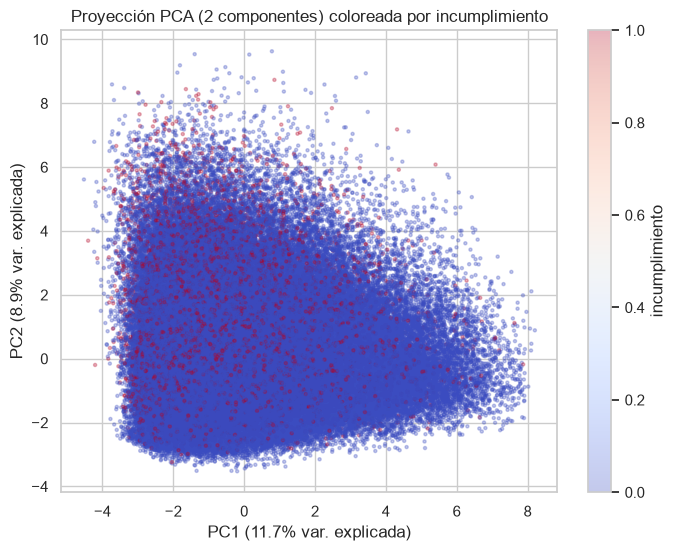

Varianza explicada acumulada (2 componentes): 20.6%


In [27]:
# 4.4 PCA complementario (exploratorio, no es insumo del modelo final)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train_prep)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap="coolwarm", alpha=0.3, s=5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var. explicada)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var. explicada)")
plt.title("Proyección PCA (2 componentes) coloreada por incumplimiento")
plt.colorbar(scatter, label="incumplimiento")
plt.show()

print(f"Varianza explicada acumulada (2 componentes): {pca.explained_variance_ratio_.sum()*100:.1f}%")


Las dos clases se solapan casi por completo en el plano PC1-PC2, sin un clúster separado de incumplimientos. Es esperable, ya que estos 2 componentes solo explican ~20.6% de la varianza total. Confirma que el PCA es exploratorio y no reemplaza a SelectKBest.

**5. Construcción del Modelo**

Baseline: Regresión Logística (simple, interpretable). Principal: Random Forest (relaciones no lineales, robusto a outliers remanentes, feature importance directa). Ambos con `class_weight='balanced'` por el desbalance de clases. Ajuste de hiperparámetros del Random Forest vía `GridSearchCV`, optimizando ROC-AUC.

In [28]:
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_sel, y_train)
y_proba_lr = log_reg.predict_proba(X_test_sel)[:, 1]


In [29]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced",
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_sel, y_train)
y_proba_rf = rf.predict_proba(X_test_sel)[:, 1]


In [30]:
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [8, 10, 12],
    "min_samples_leaf": [1, 5]
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, verbose=1
)
grid_search.fit(X_train_sel, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print(f"Mejor ROC-AUC en CV: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_proba_best = best_rf.predict_proba(X_test_sel)[:, 1]


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros: {'max_depth': 12, 'min_samples_leaf': 5, 'n_estimators': 300}
Mejor ROC-AUC en CV: 0.7415


**6. Evaluación del Modelo**

El umbral de clasificación por defecto (0.5) rara vez es óptimo con un desbalance de ~92/8: normalmente conviene bajarlo para mejorar el Recall de la clase minoritaria (detectar clientes riesgosos), que es la que más le importa al negocio. Se analiza Precision/Recall vs. umbral antes de fijar uno, en vez de usar 0.5 sin justificación.

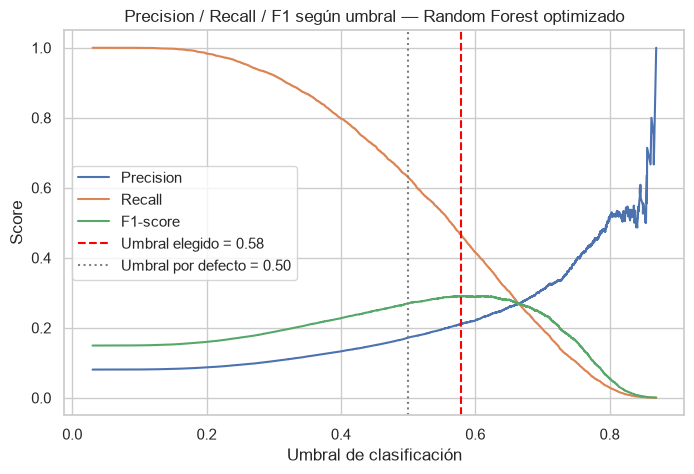

Umbral elegido (máximo F1): 0.579


In [31]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

idx_mejor_f1 = np.argmax(f1_scores[:-1])
umbral_optimo = thresholds[idx_mejor_f1]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1-score")
plt.axvline(umbral_optimo, color="red", linestyle="--", label=f"Umbral elegido = {umbral_optimo:.2f}")
plt.axvline(0.5, color="gray", linestyle=":", label="Umbral por defecto = 0.50")
plt.xlabel("Umbral de clasificación")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 según umbral — Random Forest optimizado")
plt.legend()
plt.show()

print(f"Umbral elegido (máximo F1): {umbral_optimo:.3f}")


Para tener más modelos comparativos, se busca un nuevo umbral de decisión óptimo según F1-score.

In [32]:
def evaluar_modelo(nombre, y_true, y_proba, umbral=0.5):
    y_pred = (y_proba >= umbral).astype(int)
    return {
        "Modelo": nombre,
        "Umbral": umbral,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

resultados = pd.DataFrame([
    evaluar_modelo("Regresión Logística (umbral 0.5)", y_test, y_proba_lr, 0.5),
    evaluar_modelo("Random Forest base (umbral 0.5)", y_test, y_proba_rf, 0.5),
    evaluar_modelo("Random Forest optimizado (umbral 0.5)", y_test, y_proba_best, 0.5),
    evaluar_modelo("Random Forest optimizado (umbral ajustado)", y_test, y_proba_best, umbral_optimo),
])
resultados.set_index("Modelo").round(4)


,Umbral,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,,
Regresión Logística (umbral 0.5),0.5000,0.6860,0.1585,0.6705,0.2564,0.7426
Random Forest base (umbral 0.5),0.5000,0.7031,0.1635,0.6508,0.2614,0.7427
Random Forest optimizado (umbral 0.5),0.5000,0.7251,0.1720,0.6304,0.2702,0.7449
Random Forest optimizado (umbral ajustado),0.5793,0.8171,0.2118,0.4651,0.2910,0.7449


Se aprecia un trade-off entre la mejora de accuracy/precision y la caída de recall al elegir el umbral óptimo.

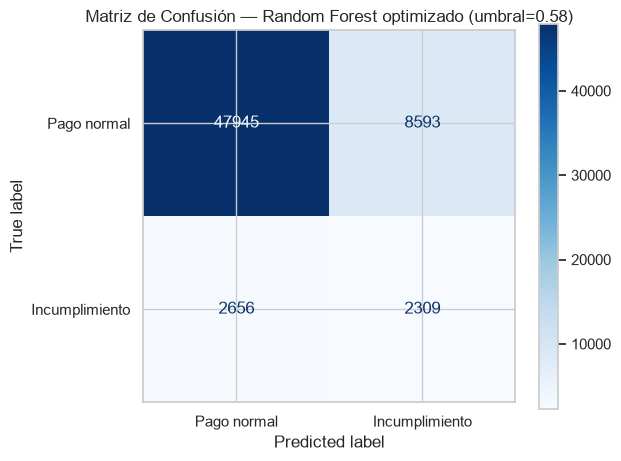

                precision    recall  f1-score   support

   Pago normal       0.95      0.85      0.90     56538
Incumplimiento       0.21      0.47      0.29      4965

      accuracy                           0.82     61503
     macro avg       0.58      0.66      0.59     61503
  weighted avg       0.89      0.82      0.85     61503



In [33]:
y_pred_final = (y_proba_best >= umbral_optimo).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pago normal", "Incumplimiento"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title(f"Matriz de Confusión — Random Forest optimizado (umbral={umbral_optimo:.2f})")
plt.show()

print(classification_report(y_test, y_pred_final, target_names=["Pago normal", "Incumplimiento"]))


La matriz de confusión con umbral óptimo no es muy determinante para el problema de negocio, ya que existen bastantes falsos positivos y falsos negativos.

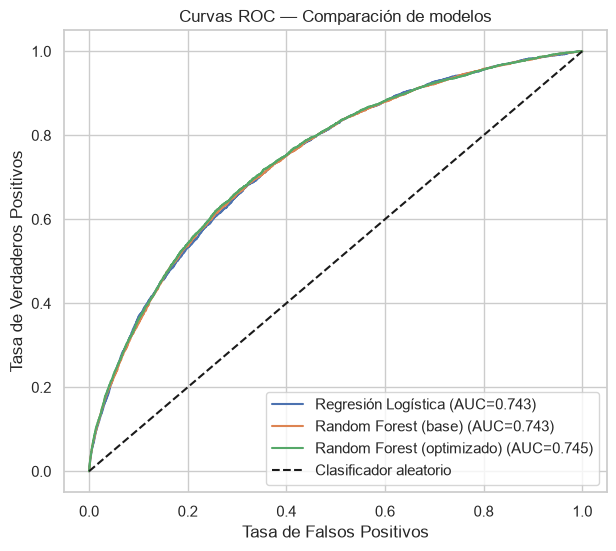

In [34]:
fig, ax = plt.subplots(figsize=(7, 6))
for nombre, proba in [("Regresión Logística", y_proba_lr),
                       ("Random Forest (base)", y_proba_rf),
                       ("Random Forest (optimizado)", y_proba_best)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curvas ROC — Comparación de modelos")
ax.legend()
plt.show()


No existe una gran diferencia entre los modelos

**7. Interpretación del Modelo y Conclusiones**

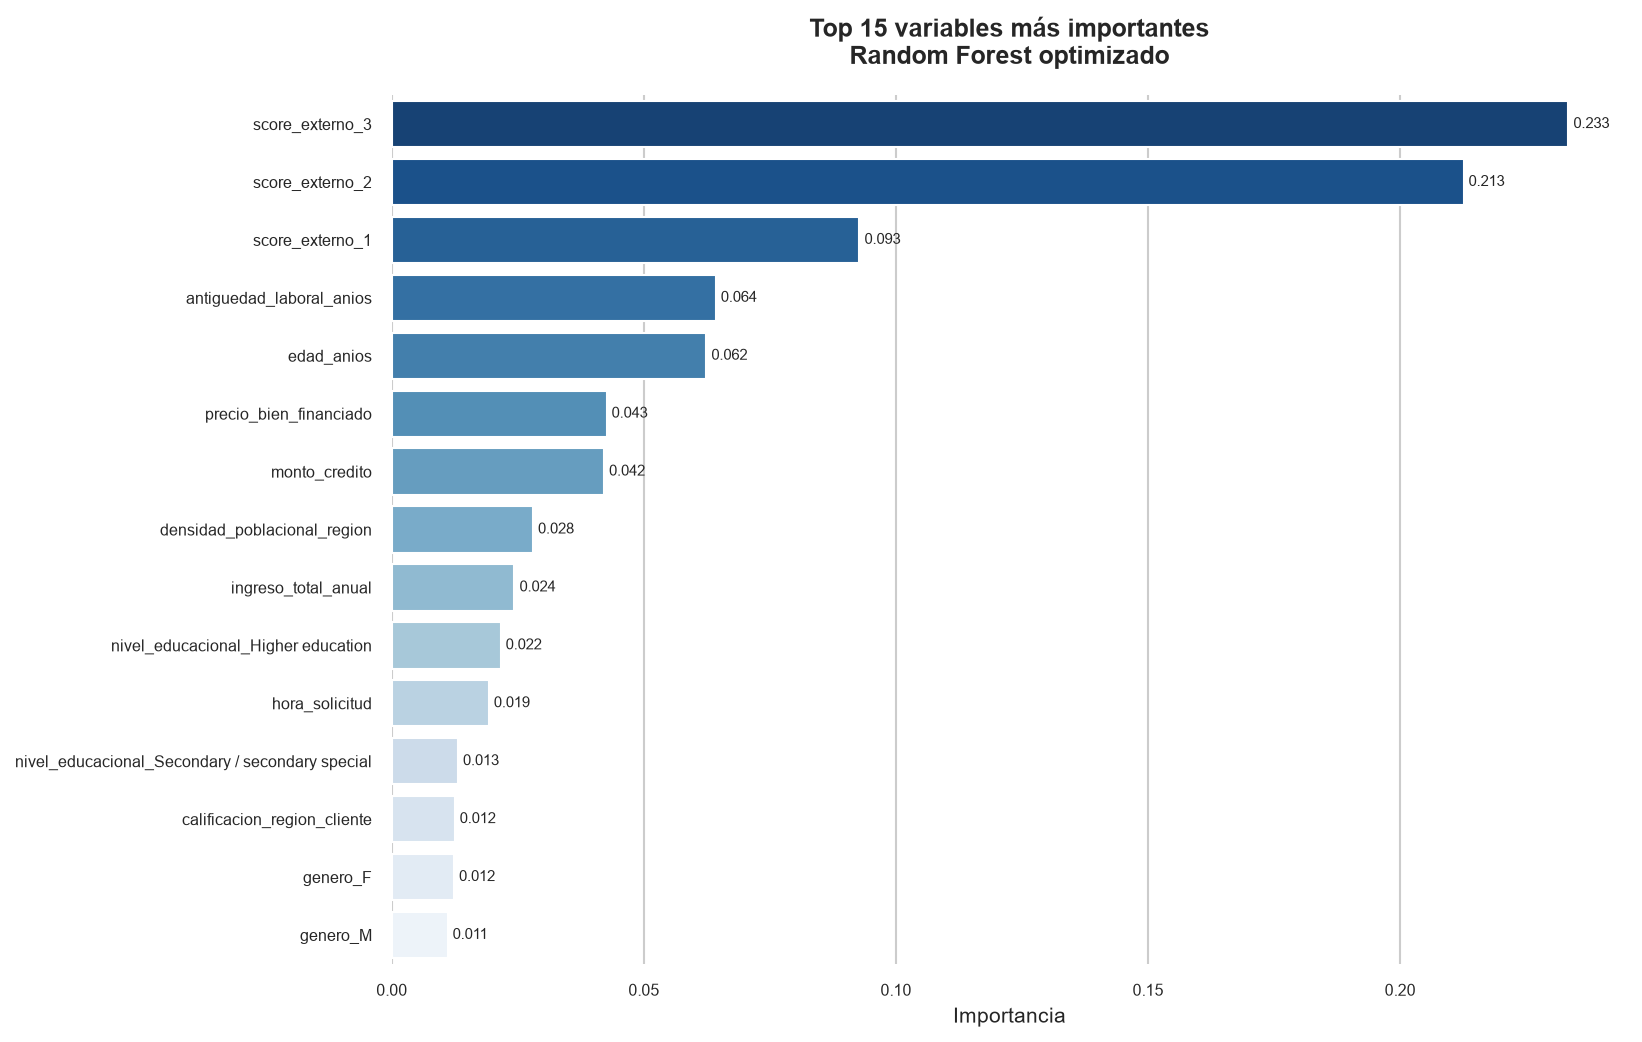

,feature,importance
8,score_externo_3,0.233355
7,score_externo_2,0.212560
6,score_externo_1,0.092755
14,antiguedad_laboral_anios,0.064253
13,edad_anios,0.062385
2,precio_bien_financiado,0.042593
1,monto_credito,0.042087
4,densidad_poblacional_region,0.027994
0,ingreso_total_anual,0.024332
24,nivel_educacional_Higher education,0.021585


In [35]:
importancias = (
    pd.DataFrame({
        "feature": selected_features,
        "importance": best_rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .head(15)
)

sns.set_theme(style="whitegrid", font_scale=0.7)
fig, ax = plt.subplots(figsize=(11, 7), dpi=150)
colors = sns.color_palette("Blues_r", n_colors=len(importancias))
sns.barplot(
    data=importancias,
    y="feature",
    x="importance",
    palette=colors,
    ax=ax
)

for i, v in enumerate(importancias["importance"]):
    ax.text(
        v + 0.001,
        i,
        f"{v:.3f}",
        va="center",
        fontsize=7
    )

ax.set_title(
    "Top 15 variables más importantes\nRandom Forest optimizado",
    fontsize=12,
    weight="bold",
    pad=15
)
ax.set_xlabel("Importancia", fontsize=10)
ax.set_ylabel("")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

display(importancias)


Los tres scores externos dominan el ranking, seguidos de edad y antigüedad laboral — coincide con lo que ya habíamos visto en la correlación del EDA y en el F-test de ANOVA. 

Fortalezas: buen ROC-AUC (robusto al desbalance); `class_weight='balanced'` evita ignorar la clase minoritaria; el ajuste explícito de umbral (en vez de 0.5 por defecto) mejora el Recall de la clase de interés; nombres de variables legibles facilitan explicar el modelo a negocio.

Limitaciones: desbalance de clases sigue limitando el Recall alcanzable; no se incorporaron tablas satélite (`bureau.csv`, `previous_application.csv`); probabilidades no calibradas.

Mejoras posibles: incorporar historial crediticio externo/previo, probar SMOTE, probar XGBoost/LightGBM, calibrar probabilidades (`CalibratedClassifierCV`).

Aplicación práctica: motor de scoring de pre-aprobación crediticia — aprobar automáticamente bajo riesgo, rechazar automáticamente alto riesgo, derivar casos intermedios a evaluación manual.

**8. Exportación del modelo**

In [36]:
# carpeta dedicada para los artefactos del modelo, creada si no existe
carpeta_modelos = "../data/output/modelos/"
os.makedirs(carpeta_modelos, exist_ok=True)

joblib.dump(best_rf, os.path.join(carpeta_modelos, "modelo_home_credit_rf.joblib"))
joblib.dump(preprocessor, os.path.join(carpeta_modelos, "preprocessor_home_credit.joblib"))
joblib.dump(selector, os.path.join(carpeta_modelos, "selector_home_credit.joblib"))
joblib.dump(umbral_optimo, os.path.join(carpeta_modelos, "umbral_clasificacion.joblib"))

print(f"Modelo y transformadores guardados en: ./{carpeta_modelos}/")
print(os.listdir(carpeta_modelos))


Modelo y transformadores guardados en: ./../data/output/modelos//
['modelo_home_credit_rf.joblib', 'preprocessor_home_credit.joblib', 'selector_home_credit.joblib', 'umbral_clasificacion.joblib']
